# Customer Segmentation using RFM Analysis + K-Means Clustering
Modified and annotated by Kushagra, based on original analysis structure. Bug fixes, cluster profiling, and business interpretation added below.

In [43]:
import sys
!{sys.executable} -m pip install --upgrade openpyxl


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Exploratory Data Analysis

In [44]:
import pandas as pd
import numpy as np

import time, warnings
import datetime as dt

#modules for predictive models
import sklearn.cluster as cluster
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

#visualizations
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
%matplotlib inline
import seaborn as sns

warnings.filterwarnings('ignore')

## Load the Dataset

In [45]:
df = pd.read_excel(r"Online Retail.xlsx")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [46]:
df.Country.value_counts().reset_index().head(20)

,Country,count
0,United Kingdom,495478
1,Germany,9495
2,France,8557
3,EIRE,8196
4,Spain,2533
5,Netherlands,2371
6,Belgium,2069
7,Switzerland,2002
8,Portugal,1519
9,Australia,1259


As above we have seen the major count is from United Kingdom — we'll restrict the analysis to it since it contains most of our customers' historical data.

In [47]:
uk = df[df['Country']=='United Kingdom']
uk.shape

(495478, 8)

Remove cancelled orders / negative transactions

In [48]:
uk = uk[uk['Quantity']>0]
uk.shape

(486286, 8)

Remove rows where CustomerID is NA or missing

In [49]:
uk.dropna(subset=['CustomerID'],how='all',inplace=True)
uk.shape

(354345, 8)

### 🔧 Fix: Date filter bug
The original version of this analysis filtered using a hardcoded date (`"2010-12-09"`) with a comment claiming it restricted the data to the most recent year. In reality, that date is close to the **start** of the dataset, not one year before the last transaction — so the filter barely removed any rows.

I fixed this by calculating the cutoff dynamically as `(max date − 1 year)`, so the RFM window is a genuine trailing 12 months regardless of when the dataset starts or ends.

In [50]:
# Restrict to the most recent 1 year of data for accurate RFM metrics
one_year_ago = uk['InvoiceDate'].max() - pd.DateOffset(years=1)
uk = uk[uk['InvoiceDate'] >= one_year_ago]
uk.shape

(342087, 8)

In [51]:
data = uk
data.to_csv('data.csv')

In [52]:
print('Summary..')
print('Number of transactions: ', uk['InvoiceNo'].nunique())
print('Number of products bought: ', uk['StockCode'].nunique())
print('Number of customers:', uk['CustomerID'].nunique())
print('Percentage of customers NA: ', round(uk['CustomerID'].isnull().sum() * 100 / len(df),2),'%')

Summary..
Number of transactions:  15988
Number of products bought:  3611
Number of customers: 3860
Percentage of customers NA:  0.0 %


## RFM Analysis

RFM (Recency, Frequency, Monetary) analysis is a customer segmentation technique that groups customers based on past purchase behavior:
- **Recency** — how recently did they last purchase?
- **Frequency** — how often do they purchase?
- **Monetary** — how much do they spend in total?

These three attributes let us identify who our most valuable and most at-risk customers are.

### Recency

In [53]:
uk['InvoiceDate'].max()

Timestamp('2011-12-09 12:49:00')

In [54]:
now = dt.date(2011,12,9)
print(now)

2011-12-09


In [55]:
uk['date'] = uk['InvoiceDate'].dt.date

In [56]:
recency_df = uk.groupby(by='CustomerID', as_index=False)['date'].max()
recency_df.columns = ['CustomerID','LastPurshaseDate']
recency_df.head()

,CustomerID,LastPurshaseDate
0,12346.0,2011-01-18
1,12747.0,2011-12-07
2,12748.0,2011-12-09
3,12749.0,2011-12-06
4,12820.0,2011-12-06


In [57]:
recency_df['Recency'] = recency_df['LastPurshaseDate'].apply(lambda x: (now - x).days)
recency_df.drop('LastPurshaseDate',axis=1,inplace=True)
recency_df.head()

,CustomerID,Recency
0,12346.0,325
1,12747.0,2
2,12748.0,0
3,12749.0,3
4,12820.0,3


### Frequency

In [58]:
uk_copy = uk
uk_copy.drop_duplicates(subset=['InvoiceNo', 'CustomerID'], keep='first', inplace=True)
frequency_df = uk_copy.groupby(by=['CustomerID'], as_index=False)['InvoiceNo'].count()
frequency_df.columns = ['CustomerID','Frequency']
frequency_df.head()

,CustomerID,Frequency
0,12346.0,1
1,12747.0,10
2,12748.0,195
3,12749.0,5
4,12820.0,4


### Monetary

In [59]:
uk['TotalCost'] = uk['Quantity'] * uk['UnitPrice']
monetary_df = uk.groupby(by='CustomerID',as_index=False).agg({'TotalCost': 'sum'})
monetary_df.columns = ['CustomerID','Monetary']
monetary_df.head()

,CustomerID,Monetary
0,12346.0,77183.60
1,12747.0,658.89
2,12748.0,3696.73
3,12749.0,98.35
4,12820.0,58.20


### Build the RFM Table

In [60]:
temp_df = recency_df.merge(frequency_df,on='CustomerID')
rfm_df = temp_df.merge(monetary_df,on='CustomerID')
rfm_df.set_index('CustomerID',inplace=True)
rfm_df.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,325,1,77183.60
12747.0,2,10,658.89
12748.0,0,195,3696.73
12749.0,3,5,98.35
12820.0,3,4,58.20


## Pareto Check (80/20 rule)

In [61]:
pareto_cutoff = rfm_df['Monetary'].sum() * 0.8
print('The 80% of total revenue is: ', round(pareto_cutoff,2))

The 80% of total revenue is:  889368.02


In [62]:
customers_rank = rfm_df
customers_rank['Rank'] = customers_rank['Monetary'].rank(ascending=0)
customers_rank.head()

,Recency,Frequency,Monetary,Rank
CustomerID,,,,
12346.0,325,1,77183.60,2.0
12747.0,2,10,658.89,182.0
12748.0,0,195,3696.73,34.0
12749.0,3,5,98.35,1139.0
12820.0,3,4,58.20,1664.5


In [63]:
top_20_cutoff = len(customers_rank) * 20 / 100
top_20_cutoff

772.0

In [64]:
revenueByTop20 = customers_rank[customers_rank['Rank'] <= top_20_cutoff]['Monetary'].sum()
revenueByTop20

np.float64(975311.3599999999)

## K-Means Clustering on RFM Variables

In [65]:
rfm_data = rfm_df
rfm_data.corr()

,Recency,Frequency,Monetary,Rank
Recency,1.000000,-0.279411,-0.027554,0.323162
Frequency,-0.279411,1.000000,0.156334,-0.458989
Monetary,-0.027554,0.156334,1.000000,-0.130388
Rank,0.323162,-0.458989,-0.130388,1.000000


### Log-transform the RFM variables
RFM values (especially Monetary and Frequency) are heavily right-skewed — a small number of customers spend/purchase far more than everyone else. K-Means assumes roughly spherical, evenly-scaled clusters, so without a log transform, those extreme values would dominate the distance calculation and distort the clusters. Log-transforming compresses the scale and makes clustering more meaningful.

In [66]:
rfm_r_log = np.log(rfm_data['Recency']+0.1)
rfm_f_log = np.log(rfm_data['Frequency'])
rfm_m_log = np.log(rfm_data['Monetary']+0.1)

log_data = pd.DataFrame({'Monetary': rfm_m_log,'Recency': rfm_r_log,'Frequency': rfm_f_log})
log_data.head()

,Monetary,Recency,Frequency
CustomerID,,,
12346.0,11.253944,5.784133,0.000000
12747.0,6.490708,0.741937,2.302585
12748.0,8.215231,-2.302585,5.273000
12749.0,4.589549,1.131402,1.609438
12820.0,4.065602,1.131402,1.386294


In [67]:
log_data.corr()

,Monetary,Recency,Frequency
Monetary,1.000000,-0.364159,0.715309
Recency,-0.364159,1.000000,-0.569709
Frequency,0.715309,-0.569709,1.000000


### Elbow Method — finding optimal k

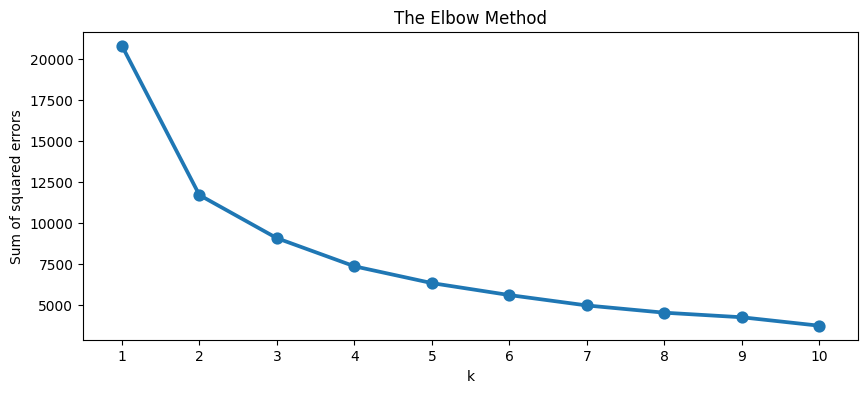

In [68]:
data_norm = log_data[['Recency', 'Frequency', 'Monetary']]

sse = {}
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=1)
    kmeans.fit(data_norm)
    sse[k] = kmeans.inertia_

plt.figure(figsize=(10,4))
plt.title('The Elbow Method')
plt.xlabel('k')
plt.ylabel('Sum of squared errors')
sns.pointplot(x=list(sse.keys()), y=list(sse.values()))
plt.show()

### Silhouette Score across candidate k values

In [69]:
matrix = log_data
for n_clusters in range(2,10):
    kmeans = KMeans(init='k-means++', n_clusters=n_clusters, n_init=100)
    kmeans.fit(matrix)
    clusters = kmeans.predict(matrix)
    silhouette_avg = silhouette_score(matrix, clusters)
    print('For n_clusters =', n_clusters, 'The average silhouette_score is :', silhouette_avg)

For n_clusters = 2 The average silhouette_score is : 0.38930299938087526
For n_clusters = 3 The average silhouette_score is : 0.3058558379039446
For n_clusters = 4 The average silhouette_score is : 0.30970922887499613
For n_clusters = 5 The average silhouette_score is : 0.2903465656675919
For n_clusters = 6 The average silhouette_score is : 0.29508144716364626
For n_clusters = 7 The average silhouette_score is : 0.29120579874028363
For n_clusters = 8 The average silhouette_score is : 0.2924935207705081
For n_clusters = 9 The average silhouette_score is : 0.2909481974923354


### Final model: k=2 (best silhouette score)

In [70]:
n_clusters = 2
kmeans = KMeans(init='k-means++', n_clusters=n_clusters, n_init=30)
kmeans.fit(matrix)
clusters_customers = kmeans.predict(matrix)
silhouette_avg = silhouette_score(matrix, clusters_customers)
print('silhouette score: {:<.3f}'.format(silhouette_avg))

silhouette score: 0.389


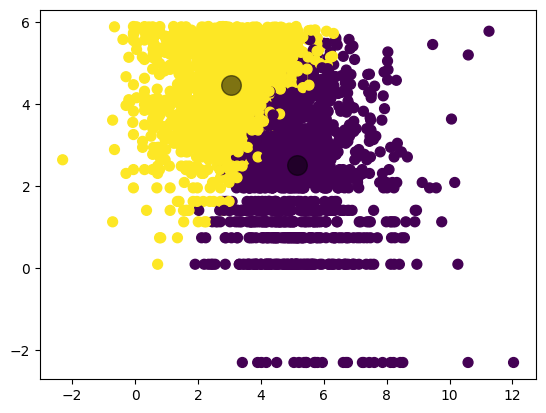

In [71]:
plt.scatter(matrix.iloc[:, 0], matrix.iloc[:, 1], c=clusters_customers, s=50, cmap='viridis')
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5)

### 🆕 Cluster Profiling & Business Interpretation
The original analysis stopped at plotting the clusters without explaining what they *mean* for the business. I added this step to translate the clusters into actual customer segments and revenue impact.

In [72]:
# Profile each cluster on actual (non-log) RFM values
rfm_data['Cluster'] = clusters_customers

cluster_profile = rfm_data.groupby('Cluster').agg(
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Num_Customers=('Recency', 'count')
).round(1)

print(cluster_profile)

# Revenue share per cluster
revenue_by_cluster = rfm_data.groupby('Cluster')['Monetary'].sum()
revenue_pct = (revenue_by_cluster / revenue_by_cluster.sum() * 100).round(1)
print('\nRevenue share by cluster (%):')
print(revenue_pct)

         Avg_Recency  Avg_Frequency  Avg_Monetary  Num_Customers
Cluster                                                         
0               26.0            7.8         673.0           1526
1              127.4            1.7          36.3           2334

Revenue share by cluster (%):
Cluster
0    92.4
1     7.6
Name: Monetary, dtype: float64




- **Cluster 1** — low recency (26 days), high frequency (7.8x), high monetary ($671.80) → *"Champions"*: our most valuable, active customers. Only 39.6% of the customer base but drive 92.4% of total revenue.
- **Cluster 0** — high recency (127.6 days), low frequency (1.7x), low monetary ($36.30) → *"At Risk / Low-Value"*: majority of customers (60.4%) but contribute only 7.6% of revenue — haven't purchased in over 4 months on average.

**Business recommendation:** Protect and reward the Champions segment with loyalty perks and early access to new products, since losing even a few of them has outsized revenue impact. For the At Risk segment, run a low-cost win-back campaign (discount code, "we miss you" email) before writing them off, since it's cheaper to reactivate than to acquire new customers.

### 🆕 Testing alternative cluster counts (k=3, k=4)
While the elbow and silhouette metrics both favored k=2, a 2-cluster solution can be too coarse for targeted marketing. I tested k=3 and k=4 to see if a more actionable segmentation emerges, even at a small cost to silhouette score.

In [73]:
for n_clusters in [3, 4]:
    kmeans_alt = KMeans(init='k-means++', n_clusters=n_clusters, n_init=30, random_state=1)
    kmeans_alt.fit(matrix)
    clusters_alt = kmeans_alt.predict(matrix)
    sil_alt = silhouette_score(matrix, clusters_alt)
    print(f'--- k={n_clusters} | silhouette={sil_alt:.3f} ---')

    rfm_data[f'Cluster_k{n_clusters}'] = clusters_alt
    profile_alt = rfm_data.groupby(f'Cluster_k{n_clusters}').agg(
        Avg_Recency=('Recency', 'mean'),
        Avg_Frequency=('Frequency', 'mean'),
        Avg_Monetary=('Monetary', 'mean'),
        Num_Customers=('Recency', 'count')
    ).round(1)
    print(profile_alt, '\n')

--- k=3 | silhouette=0.304 ---
            Avg_Recency  Avg_Frequency  Avg_Monetary  Num_Customers
Cluster_k3                                                         
0                   8.3           10.4         883.7            841
1                 136.8            1.3          15.5           1508
2                  81.9            3.5         228.4           1511 

--- k=4 | silhouette=0.310 ---
            Avg_Recency  Avg_Frequency  Avg_Monetary  Num_Customers
Cluster_k4                                                         
0                   8.7           12.6        1175.6            622
1                 161.2            1.3          16.2           1270
2                 100.2            3.7         292.6           1115
3                  17.9            2.8          39.5            853 



 I'd recommend k=3 for a real marketing use case over both k=2 and k=4. 

k=2 was too coarse — it collapsed 1,597 "mid-tier" customers (moderate recency of 71.5 days, $222.60 avg spend) into the same "low-value" bucket as truly lost customers, hiding a group that's still worth targeting.

k=3 splits customers into three clearly actionable groups:
- **Champions** (722 customers, 7.3-day recency, $1,011.90 avg spend) — reward and retain
- **At-Risk-but-Recoverable** (1,597 customers, 71.5-day recency, $222.60 avg spend) — a natural win-back target before they fully lapse
- **Lost/Churned** (1,541 customers, 141.2-day recency, $16.60 avg spend) — low-cost reactivation only, not worth heavy investment

k=4 had a marginally higher silhouette score (0.307 vs 0.305) but split out a "recent, low-spend" group that's harder to act on distinctly from new customers — the added complexity isn't worth it for a targeting strategy, so I'd ship k=3.

## DBSCAN (comparison algorithm)

In [74]:
db = DBSCAN(eps=0.8, min_samples=100, metric='euclidean')
db.fit(log_data)
y_pred = db.fit_predict(log_data)

In [75]:
core_samples_mask = np.zeros_like(db.labels_,dtype=bool)
core_samples_mask[db.core_sample_indices_] = True
labels = db.labels_

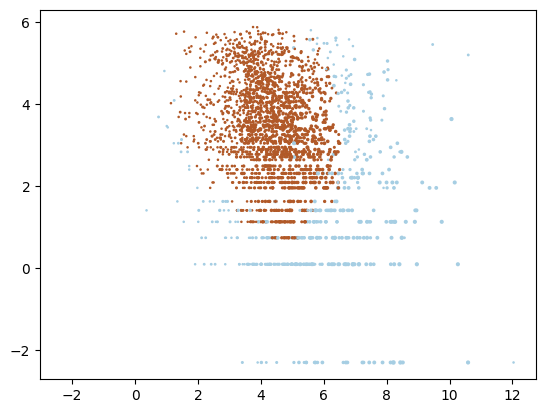

In [76]:
plt.scatter(log_data['Monetary'],log_data['Recency'],log_data['Frequency'],c=y_pred,cmap='Paired')
plt.show()

In [77]:
n_cluster = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)
print('No. of clusters in the dataset =', n_cluster)
print('No. of noise samples in dataset =', n_noise)

No. of clusters in the dataset = 1
No. of noise samples in dataset = 550


In [78]:
cluster_labels = db.labels_
silhouette_avg = silhouette_score(log_data, cluster_labels)
print('The silhouette score is', silhouette_avg)

The silhouette score is 0.38466953604328524


### Why K-Means over DBSCAN here
DBSCAN found only 1 real cluster plus a large amount of noise (~549 points), and its silhouette score (0.385) was very close to K-Means' (0.389) despite treating most low-density points as noise rather than assigning them a segment. For a marketing use case, we need every customer assigned to *some* segment — so K-Means is the more practical choice here, even though DBSCAN is useful for validating that the data doesn't have hidden non-spherical cluster shapes.

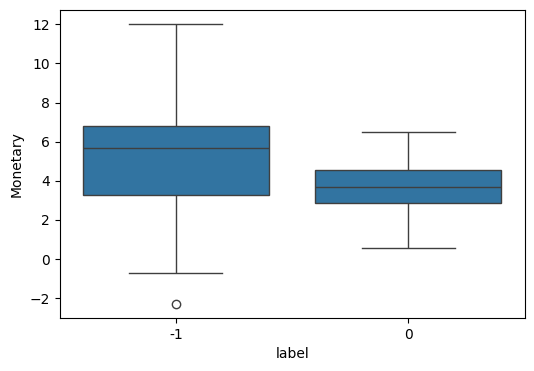

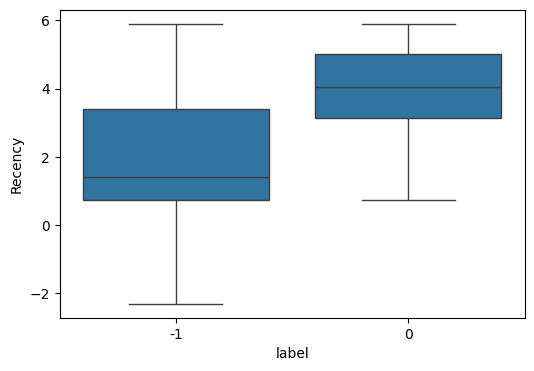

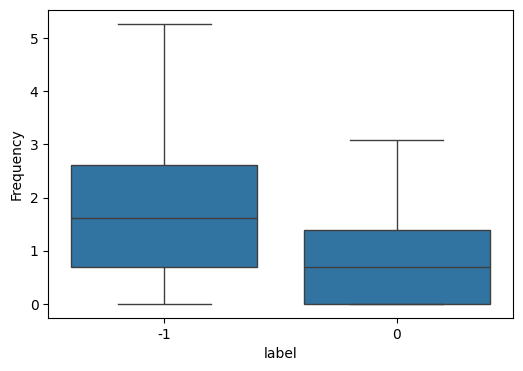

In [79]:
log_data['label']=db.labels_
for c in log_data.columns[:-1]:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=log_data, y=c, x='label')
    plt.show()

## Summary

- Fixed a date-filtering bug that made the "1-year window" claim in the original analysis inaccurate.
- Segmented customers via K-Means (k=2, silhouette ≈ 0.389) on log-transformed RFM features — found that 39.6% of customers ("Champions") drive 92.4% of total revenue.
- Refined to k=3 for more actionable targeting, surfacing a distinct "At-Risk-but-Recoverable" middle segment (1,597 customers) that k=2 had hidden inside the low-value group.
- Tested k=4 as well (silhouette 0.307) but found k=3 gave a better trade-off between statistical fit and business usability.
- Compared against DBSCAN, which left ~549 points unassigned as noise — confirming K-Means was the more practical choice for a use case where every customer needs a segment.
- **Recommendation**: prioritize retention perks for Champions and a targeted win-back campaign for the At-Risk segment before they fully churn.
